In [1]:
import numpy as np
from collections import OrderedDict
import math
import numpy as np
import pandas as pd
import pymeasure
from time import sleep, time
from matplotlib import pyplot as plt
from matplotlib import style
from datetime import datetime
from pymeasure.instruments.keithley import Keithley2450
from pymeasure.instruments.keithley import Keithley2000
import matplotlib.cm as cm
from glob import glob
import os
import sys

In [2]:
myKeithley = Keithley2450(4)

In [3]:
def get_current_and_confirm():
    questionable = myKeithley.current
    pwrOf2 = math.frexp(questionable)[1]
    while not((pwrOf2 < -20) & (pwrOf2 > -40)):
        questionable = myKeithley.current
        pwrOf2 = math.frexp(questionable)[1]
        print(f"get_current_and_confirm: Waiting for Current= {questionable} pwrOf2= {pwrOf2}")
        sleep(0.5)
    return questionable

def get_source_voltage_and_confirm():
    questionable = myKeithley.source_voltage
    pwrOf2 = math.frexp(questionable)[1]
    while not((pwrOf2 > -4)):
        questionable = myKeithley.source_voltage
        pwrOf2 = math.frexp(questionable)[1]
        sleep(0.5)
    return questionable

print(get_current_and_confirm())
print(get_source_voltage_and_confirm())

1.982358e-11
15.0


In [4]:
# myKeithley.adapter.connection.timeout
def ramp_to_voltage_and_confirm(desiredvoltage,stepsize = 0.5,pause=0.2):
    print(f"setting voltage to {desiredvoltage}")
    myKeithley.ramp_to_voltage(desiredvoltage, stepsize=stepsize, pause=pause)

    nowishVoltage = np.nan
    # nowishVoltage2 = np.nan

    while np.isclose(nowishVoltage,desiredvoltage,rtol=1e-4) == False: #atol=0.001
        try:
            nowishVoltage = get_source_voltage_and_confirm() #myKeithley.source_voltage
            # nowishVoltage = myKeithley.voltage
        except:
            print("it didn't like it")

        print(f"voltage at {nowishVoltage}, and desired voltage is {desiredvoltage}, and np.isclose is {np.isclose(nowishVoltage,desiredvoltage,rtol=1e-4)}")
        sleep(2)
    
    print(f"Finalized voltage at {myKeithley.source_voltage}")

In [5]:
print(get_current_and_confirm())
print(get_source_voltage_and_confirm())

1.837027e-11
15.0


In [6]:
def gating_rxx(Vmin, Vmax, Vstep, average,file_path,sample_name):
    VdataPoints= int(np.absolute(Vmax-Vmin)/Vstep)+1
    voltages = np.linspace(Vmin,Vmax,num=VdataPoints)
    data = OrderedDict()
    data['Voltage'], data['leakage'] = [], []
    filename = file_path+'gating2point'+sample_name+'.csv'
    
    # if np.absolute(Vmin/VdataPoints) > 0.1:
    #     myKeithley.ramp_to_voltage(Vmin, steps = int(np.absolute(Vmin/0.25)), pause=0.3)    
    # # Set the ramp rate to Vmin
    # print ('waiting for initial voltage')
    # while abs(myKeithley.source_voltage - Vmin)>0.5:
    #     sleep(3)
    # print ('Intial voltage set at : ' + str(Vmin))
    # sleep(delay)


    for v in voltages:
        ramp_to_voltage_and_confirm(v)
        # while abs(myKeithley.source_voltage - i)>0.5:
        #     sleep(1)
        # sleep(delay)
        # print ('Voltage : ' + str(i) + ' checked and stabilized')
        # sleep(delay)

        data['Voltage'].append(v)
        current = get_current_and_confirm()
        print('Current : ' + str(current) + 'A')
        data['leakage'].append(current)
        
        plt.plot(data['Voltage'], data['leakage'])
        plt.xlabel('Gate Voltage',fontsize=18)
        plt.ylabel('Leakage',fontsize=18)
        
        print(f'Measurement done for voltage : {v} ')
        datafram = pd.DataFrame({ 'Voltage': np.transpose(data['Voltage']), 'leakage':np.transpose(data['leakage'])})
        #save dataframe to csv file in the same path and file name
        datafram.to_csv(filename,index=False) 
        # following doesn't work because file is already appendedd above
        # mode='a',header=not os.path.exists(filename)

    #reset voltage after experiment
    # myKeithley.ramp_to_voltage(0, steps = int(VdataPoints), pause=0.2)


In [7]:
myKeithley.source_voltage_range = 3
myKeithley.source_voltage_range

20.0

setting voltage to -1.0
[-10.   -9.5  -9.   -8.5  -8.   -7.5  -7.   -6.5  -6.   -5.5  -5.   -4.5
  -4.   -3.5  -3.   -2.5  -2.   -1.5  -1. ]
it didn't like it
voltage at nan, and desired voltage is -1.0, and np.isclose is False
voltage at -1.0, and desired voltage is -1.0, and np.isclose is True
Finalized voltage at -1.0
get_current_and_confirm: Waiting for Current= 9.988604e-12 pwrOf2= -36
Current : 9.988604e-12A
Measurement done for voltage : -1.0 
setting voltage to -0.9
[ 9.429052e-12 -4.500000e-01 -9.000000e-01]
voltage at -1.0, and desired voltage is -0.9, and np.isclose is False
voltage at -0.9, and desired voltage is -0.9, and np.isclose is True
Finalized voltage at -0.9
get_current_and_confirm: Waiting for Current= 3.796961e-12 pwrOf2= -37
Current : 3.796961e-12A
Measurement done for voltage : -0.9 
setting voltage to -0.8
[ 3.121984e-12 -4.000000e-01 -8.000000e-01]
voltage at -0.9, and desired voltage is -0.8, and np.isclose is False
voltage at -0.8, and desired voltage is -0

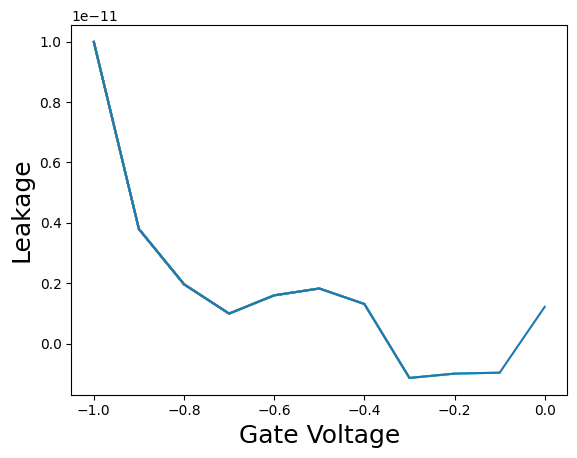

In [9]:
file_path='C:/Users/Ralph Group/Documents/Data/TiffanyFilms/NiFerritePostGraphene/IV/'
sample_name='NIFO_grapheneGate_laserOn_postZapData_1'
average = 1
gating_rxx(-1, 0, 0.1, average,file_path,sample_name)

In [27]:
myKeithley.current_limit

AttributeError: 'Keithley2450' object has no attribute 'current_limit'

In [ ]:
# myKeithley.current

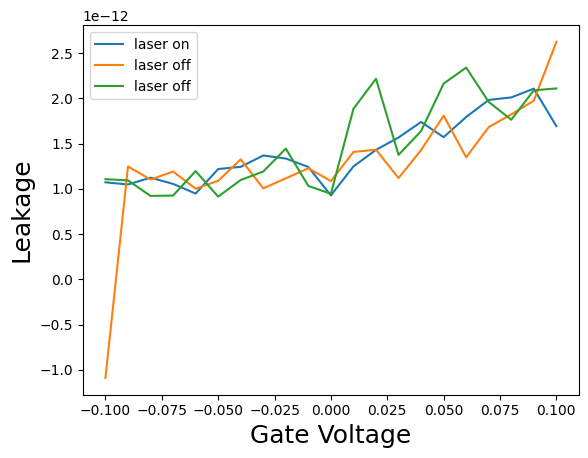

In [45]:
plt.figure()

df = pd.read_csv(r'c:\Users\Ralph Group\Documents\Data\TiffanyFilms\NiFerritePostGraphene\IV\gating2pointNIFO_grapheneGate_4.csv')
plt.plot(df['Voltage'], df['leakage'], label='laser on')

df = pd.read_csv(r'c:\Users\Ralph Group\Documents\Data\TiffanyFilms\NiFerritePostGraphene\IV\gating2pointNIFO_grapheneGate_laseroff_0.csv')
plt.plot(df['Voltage'], df['leakage'], label='laser off')

df = pd.read_csv(r'c:\Users\Ralph Group\Documents\Data\TiffanyFilms\NiFerritePostGraphene\IV\gating2pointNIFO_grapheneGate_laseroff_1.csv')
plt.plot(df['Voltage'], df['leakage'], label='laser off')

plt.xlabel('Gate Voltage',fontsize=18)
plt.ylabel('Leakage',fontsize=18)
plt.legend()

In [119]:
for i in range(1000):
    print(myKeithley.current)
    sleep(1)

-1.054848e-10
-1.143935e-10
-1.238744e-10
-1.173079e-10
-1.137496e-10
-1.118141e-10
-1.185748e-10
-9.082335e-11
-8.386911e-11
-80.0
1.384562e-11
1.394064e-11
1.388081e-11
1.408914e-11
1.373513e-11
1.368375e-11
1.385266e-11
1.400186e-11
1.399905e-11
1.380621e-11
1.37661e-11
1.386463e-11
1.401524e-11
1.370979e-11
1.394627e-11
1.392797e-11
1.385196e-11
1.364505e-11
1.40821e-11
1.405183e-11
1.386604e-11
1.380833e-11
1.387519e-11
1.385407e-11
1.392727e-11
1.375343e-11
1.394205e-11
1.37471e-11
1.374076e-11
1.375484e-11
1.397653e-11
1.374076e-11
1.400891e-11
1.403706e-11
1.373654e-11
1.371472e-11
1.373654e-11
1.39526e-11
1.37471e-11
1.384352e-11
1.399202e-11
1.397935e-11
1.394346e-11
1.392656e-11
1.37485e-11
1.399342e-11
1.377595e-11
1.392868e-11
1.388363e-11
1.378017e-11
1.385478e-11
1.39336e-11
1.370557e-11
1.401172e-11
1.389559e-11
1.381888e-11
1.372246e-11
1.393853e-11
1.390193e-11
1.377384e-11
1.404761e-11
1.407858e-11
1.376328e-11
1.384e-11
1.398709e-11
1.385055e-11
1.378651e-11
1.38322

: 